## **0. INTRODUCTION**

Oleh Tim: Kotakin aja boy
- Achmad Baihaqie Wibowo (S1 Informatika - Telkom University)
- Rafi Dzaki Azhari (S1 Informatika - Telkom University)
- Jean Yudhistira Diva Waluyo (S1 Informatika - Telkom University)

Permasalahan:

> Sektor pembiayaan mikro dan UMKM di Indonesia memiliki peran penting dalam pertumbuhan ekonomi nasional, terutama karena mayoritas pelaku usaha berada pada skala kecil dan menengah. Dalam beberapa tahun terakhir, layanan pendanaan digital mulai dari pinjaman modal usaha hingga pembiayaan sektor perdagangan mengalami percepatan signifikan berkat hadirnya teknologi finansial (*fintech*). Transformasi ini mendorong peningkatan akses pembiayaan bagi pelaku usaha di berbagai provinsi, termasuk mereka yang sebelumnya sulit mendapatkan kredit dari lembaga keuangan tradisional. Di sisi lain, perkembangan cepat ini juga menghadirkan tantangan baru, terutama terkait manajemen risiko kredit dan tingkat gagal bayar. Variasi sektor usaha, latar belakang pendidikan peminjam, jenis jaminan, serta karakteristik lokasi menjadi faktor penting dalam menentukan stabilitas ekosistem pembiayaan. Oleh karena itu, analisis berbasis data dan kecerdasan buatan semakin dibutuhkan untuk memetakan pola risiko, meningkatkan akurasi penilaian kredit, dan mendukung pertumbuhan pembiayaan yang berkelanjutan di Indonesia. 

Tujuan:
- Memprediksi status gagal bayar dari tiap transaksi yang diberikan.

Spesifikasi Masalah:
- Learning Paradigm: Supervised Learning
- ML task: Binary Classification

Tentang Dataset:
- train.csv = digunakan untuk eksplorasi hingga pengembangan model prediktif.
- test.csv = digunakan untuk memprediksi status gagal bayar dari tiap transaksi yang ada.
- sample_submission.csv = digunakan untuk acuan format struktur dataset *submission* kompetisi.

Tautan Kompetisi: https://www.kaggle.com/competitions/adikara-2025-indonesia-kredit-macet .

## 1. Import Library and Initial Setup

In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
import os
from scipy import stats
import joblib

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import chi2

# set reproducibility
SEED = 42
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_reproducibility(SEED)

# ignore warning
import warnings
warnings.filterwarnings('ignore')

catatan *reproducibility* & *randomness*: https://medium.com/data-science/random-seeds-and-reproducibility-933da79446e3 

## 2. Load Data 

In [246]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv("data/test.csv")

df_train['tanggal_pencairan'] = pd.to_datetime(df_train['tanggal_pencairan'])
df_test['tanggal_pencairan'] = pd.to_datetime(df_test['tanggal_pencairan'])

In [247]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20012 entries, 0 to 20011
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_transaksi               20012 non-null  int64         
 1   tanggal_pencairan          20012 non-null  datetime64[ns]
 2   provinsi                   20012 non-null  object        
 3   jenis_pinjaman             19543 non-null  object        
 4   status_peminjam            20012 non-null  object        
 5   jumlah_pinjaman            20012 non-null  float64       
 6   total_pengembalian         17947 non-null  float64       
 7   durasi_hari                19212 non-null  float64       
 8   porsi_pengembalian_lender  18052 non-null  float64       
 9   sektor_usaha               20012 non-null  object        
 10  pendidikan                 20012 non-null  object        
 11  jenis_jaminan              20012 non-null  object        
 12  stat

## 3. Exploratory Data Analysis

### 3.1. Initial Exploration

In [248]:
print(f'training set memiliki {df_train.shape[0]} baris dan {df_train.shape[1]} kolom.')
print(f'test set memiliki {df_test.shape[0]} baris dan {df_test.shape[1]} kolom.')

training set memiliki 20012 baris dan 13 kolom.
test set memiliki 5003 baris dan 12 kolom.


In [249]:
# categorize features
numerical = ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender']
numerical_continuous  = ['jumlah_pinjaman', 'total_pengembalian', 'porsi_pengembalian_lender']
numerical_discrete = ['durasi_hari']
categorical = ['provinsi', 'jenis_pinjaman', 'status_peminjam', 'sektor_usaha', 'pendidikan', 'jenis_jaminan']
categorical_nominal = ['provinsi', 'jenis_pinjaman', 'sektor_usaha', 'jenis_jaminan']
categorical_ordinal = ['pendidikan']
categorical_binary = ['status_peminjam']
date_feature = ['tanggal_pencairan']

# identifikasi target
categorical_binary_target = ['status_gagal_bayar']

### 3.2 Univariate Analysis

#### 3.2.1 Numerical Features

In [250]:
def describe_numerical_features_full(df, features):
    summary = []
    for col in features:
        s = df[col].dropna()
        summary.append({
            'feature': col,
            'mean': s.mean(),
            'median': s.median(),
            'mode': s.mode().iloc[0] if not s.mode().empty else None,
            'min': s.min(),
            'q1': s.quantile(0.25),
            'q3': s.quantile(0.75),
            'max': s.max(),
            'iqr': s.quantile(0.75) - s.quantile(0.25),
            'variance': s.var(),
            'std_dev': s.std(),
            'skewness': s.skew(),
            'kurtosis': s.kurt()
        })
    return pd.DataFrame(summary)

numerical_summary = describe_numerical_features_full(df_train, ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender'])
numerical_summary

,feature,mean,median,mode,min,q1,q3,max,iqr,variance,std_dev,skewness,kurtosis
0,jumlah_pinjaman,"2,098,989.01","636,000.00","174,000.00",0.00,"275,000.00","1,384,000.00","2,580,849,000.00","1,109,000.00","615,277,908,681,704.12","24,804,796.08",80.01,"7,537.65"
1,total_pengembalian,"2,273,858.58","656,000.00","267,000.00",0.00,"280,000.00","1,429,000.00","2,851,838,000.00","1,149,000.00","886,288,827,040,626.62","29,770,603.40",77.00,"6,777.58"
2,durasi_hari,9.04,7.00,7.00,-1.00,7.00,7.00,"1,096.00",0.00,314.24,17.73,26.93,"1,214.73"
3,porsi_pengembalian_lender,"362,513.79","115,000.00",0.00,0.00,"30,000.00","287,000.00","218,267,000.00","257,000.00","6,199,153,745,031.60","2,489,809.98",52.49,"3,765.09"


#### 3.2.2 Categorical Features

In [251]:
df_train.describe(include='object')

,provinsi,jenis_pinjaman,status_peminjam,sektor_usaha,pendidikan,jenis_jaminan
count,20012,19543,20012,20012,20012,20012
unique,4,5,2,6,4,4
top,Jawa Barat,Modal_Usaha,Peminjam_Berulang,Jasa,SMA,BPKB
freq,5078,17686,19791,3664,8051,5083


#### 3.2.3 Datetime Features

In [252]:
df_train.describe(include='datetime64[ns]')

,tanggal_pencairan
count,20012
mean,2023-10-20 12:50:13.551868928
min,2022-10-04 00:00:00
25%,2023-08-10 00:00:00
50%,2023-09-16 00:00:00
75%,2023-10-24 00:00:00
max,2025-11-14 00:00:00


#### 3.2.4 Necessary Visualization

##### 3.2.4.1 Numerical Features

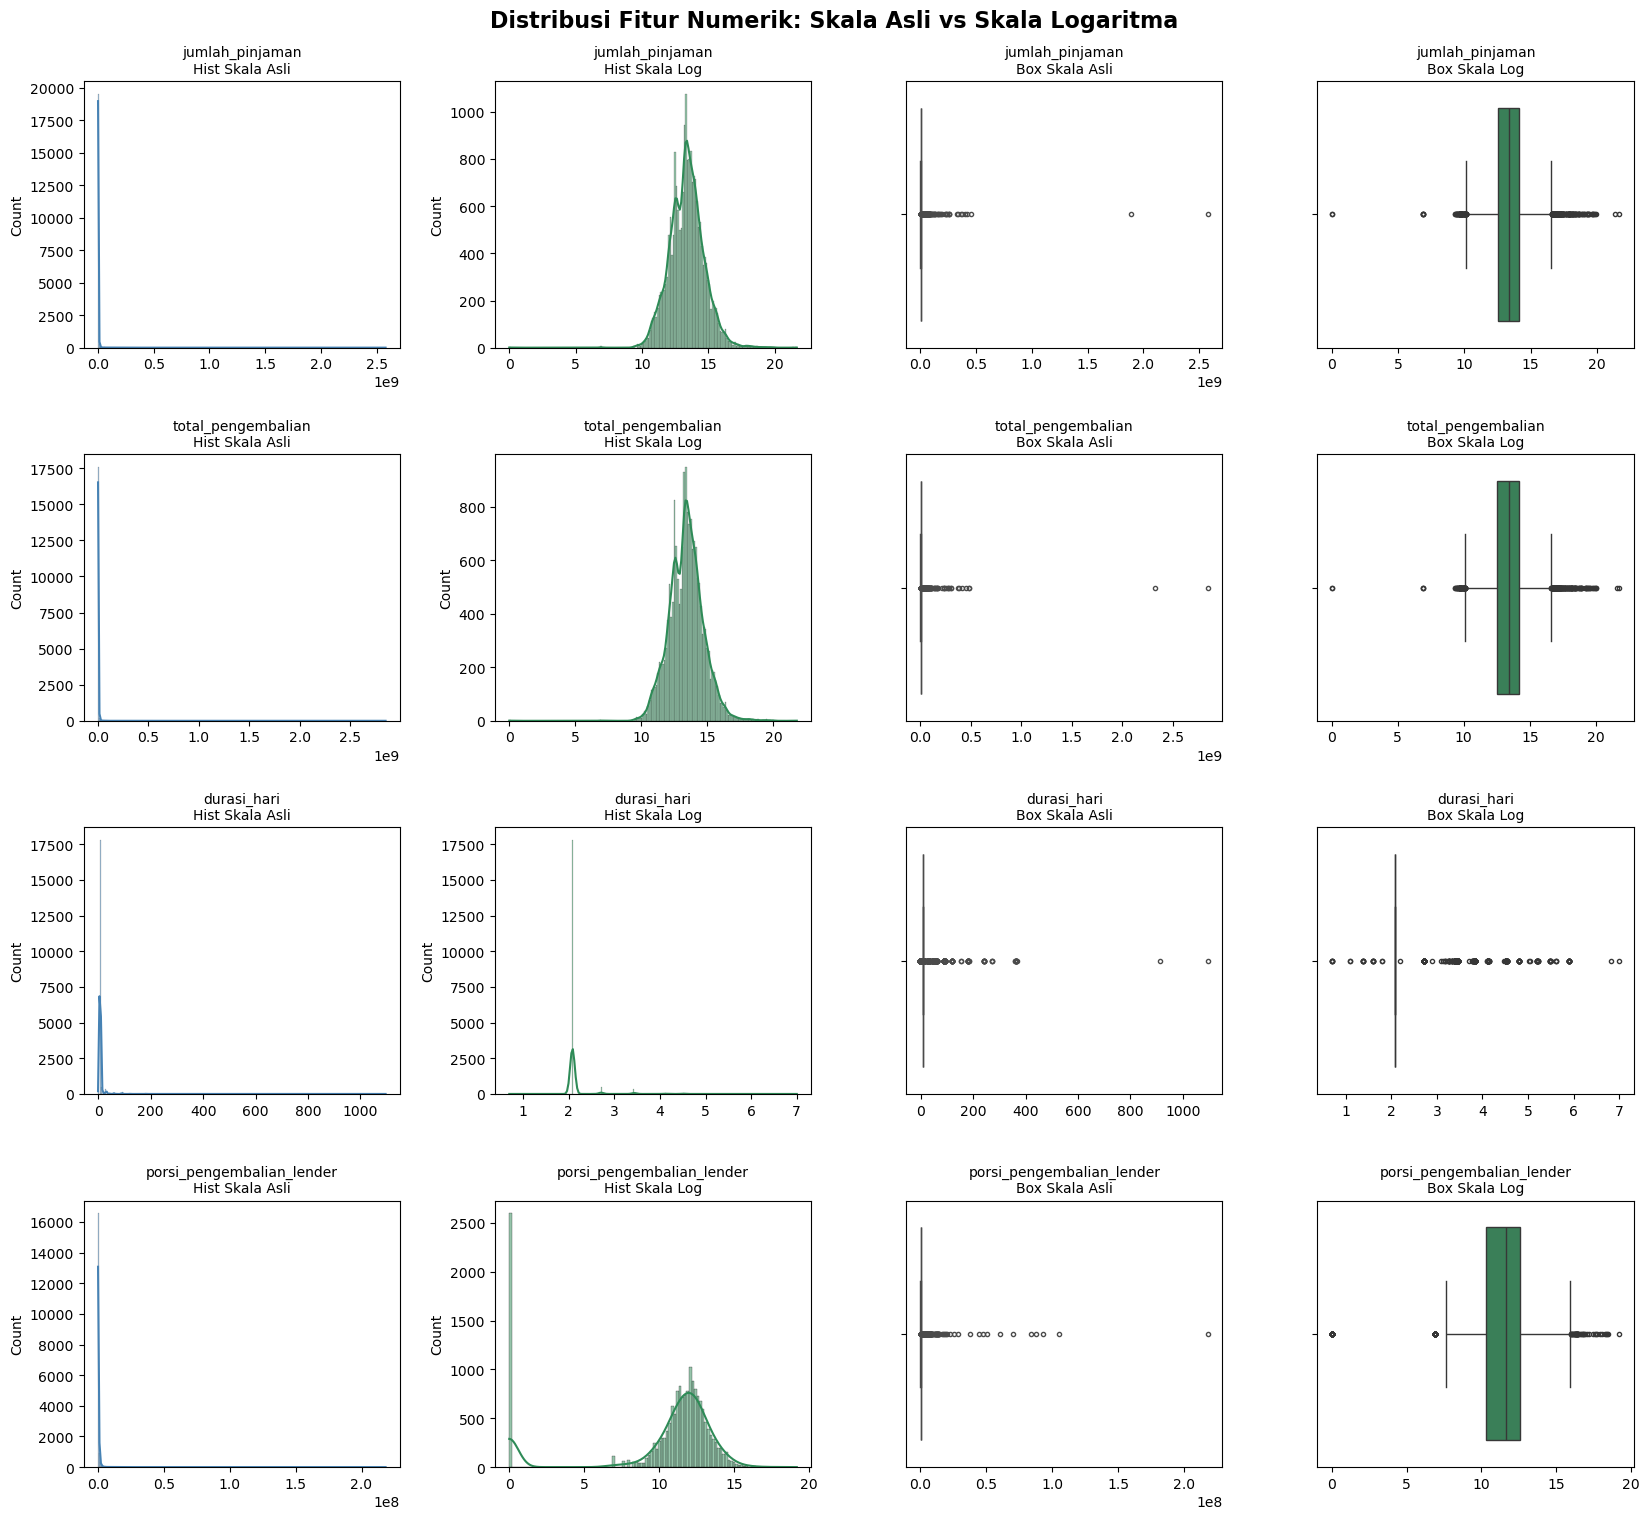

In [253]:
# define figure
fig, axes = plt.subplots(nrows=len(['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender']), ncols=4, figsize=(20, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, col in enumerate(['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender']):
    # log transform
    data_asli = df_train[col]
    data_log = np.log1p(df_train[col])
    
    # histogram: original scale
    sns.histplot(data_asli, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{col}\nHist Skala Asli', fontsize=10)
    
    # histogram: log scale
    sns.histplot(data_log, kde=True, ax=axes[i, 1], color='seagreen')
    axes[i, 1].set_title(f'{col}\nHist Skala Log', fontsize=10)
    
    # boxplot: original scale
    sns.boxplot(x=data_asli, ax=axes[i, 2], color='steelblue', fliersize=3)
    axes[i, 2].set_title(f'{col}\nBox Skala Asli', fontsize=10)
    
    # boxplot: log scale
    sns.boxplot(x=data_log, ax=axes[i, 3], color='seagreen', fliersize=3)
    axes[i, 3].set_title(f'{col}\nBox Skala Log', fontsize=10)

    # delete label on x-axis for clean visualization
    for j in range(4):
        axes[i, j].set_xlabel('')

fig.suptitle('Distribusi Fitur Numerik: Skala Asli vs Skala Logaritma', fontsize=16, fontweight='bold', y=0.92)
plt.show()

##### 3.2.4.2 Categorical Features

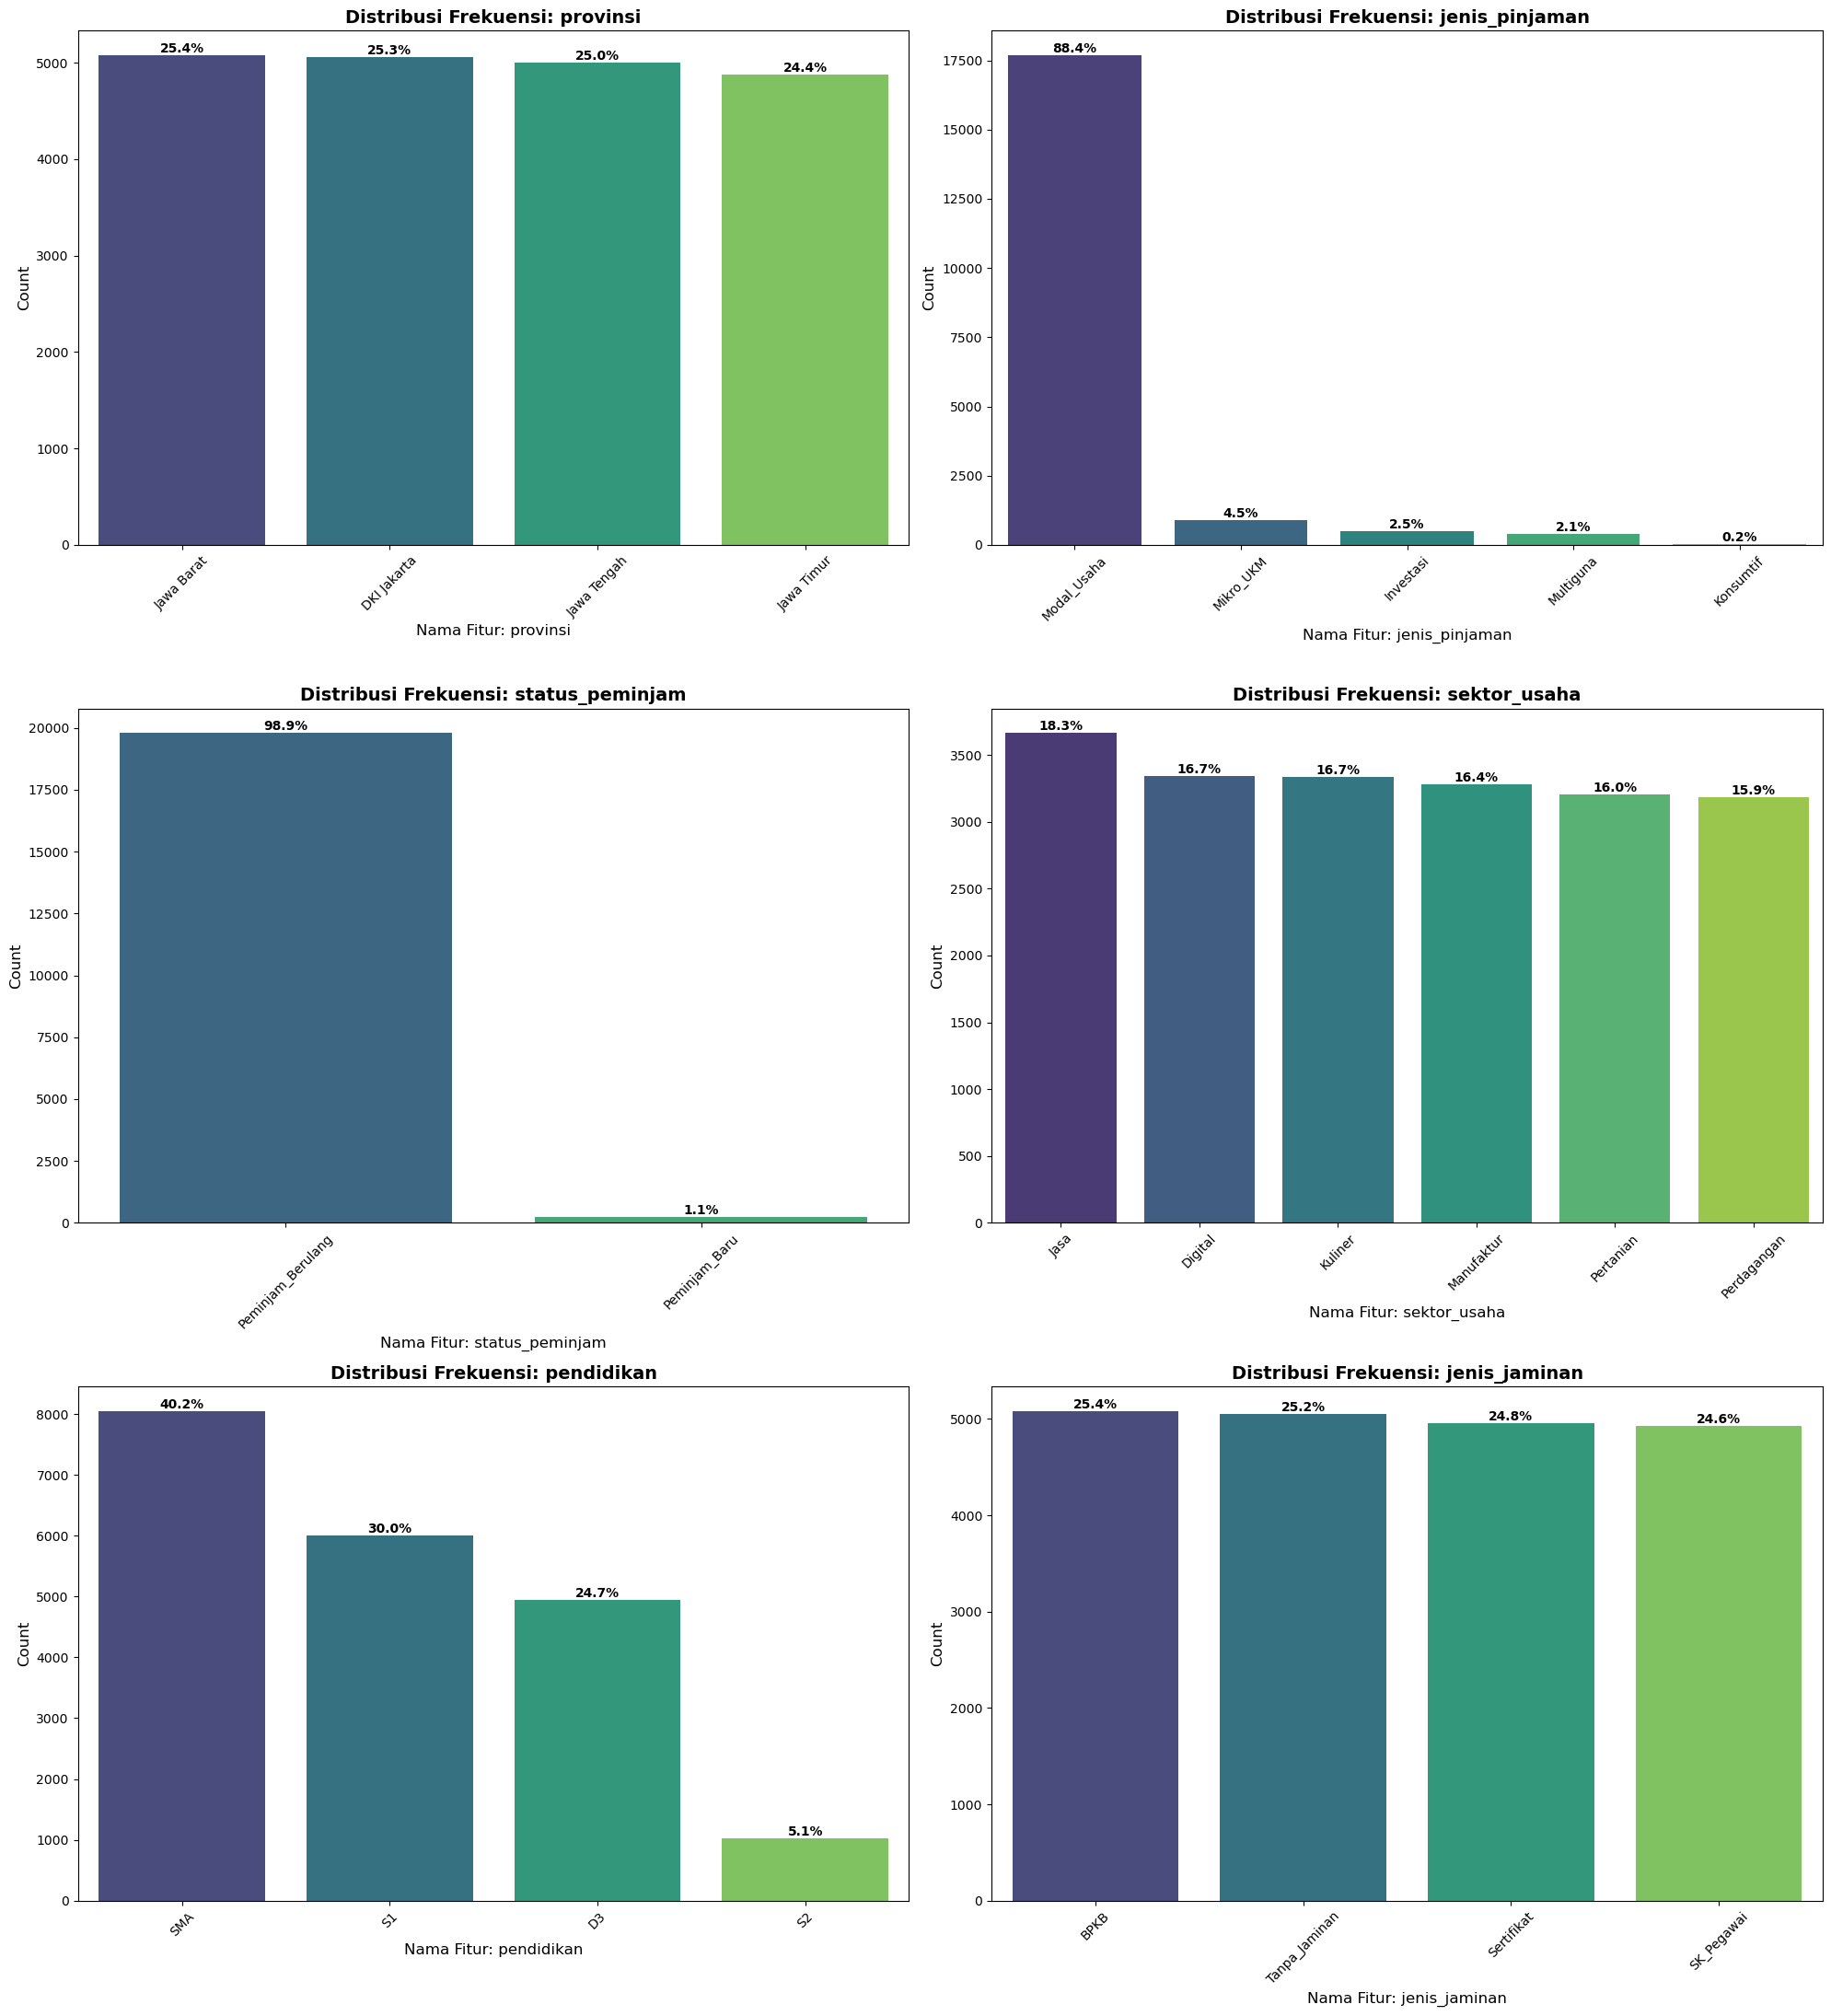

In [254]:
# define figure
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(['provinsi', 'jenis_pinjaman', 'status_peminjam', 'sektor_usaha', 'pendidikan', 'jenis_jaminan']):
    # create countplot
    ax = axes[i]
    sns.countplot(data=df_train, x=col, ax=ax, palette='viridis', order=df_train[col].value_counts().index)
    
    # customize label and title
    ax.set_title(f'Distribusi Frekuensi: {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Nama Fitur: {col}', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    
    # rotate x label
    ax.tick_params(axis='x', rotation=45)
    
    # add percentage on bars
    total = len(df_train[col])
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

# adjust layout
plt.tight_layout()
plt.show()

##### 3.2.4.3 Target Variable

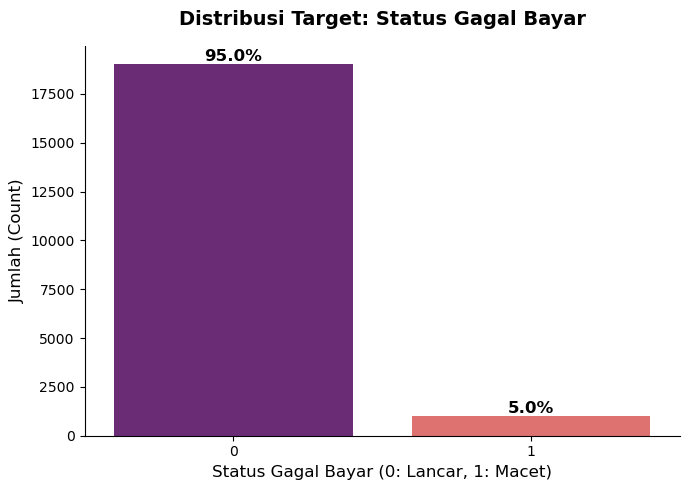

In [255]:
# define figure
plt.figure(figsize=(7, 5))

# create countplot
ax = sns.countplot(data=df_train, x='status_gagal_bayar', palette='magma', order=df_train['status_gagal_bayar'].value_counts().index)

# define title and label
plt.title('Distribusi Target: Status Gagal Bayar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Gagal Bayar (0: Lancar, 1: Macet)', fontsize=12)
plt.ylabel('Jumlah (Count)', fontsize=12)

# add percentage on bar
total = len(df_train['status_gagal_bayar'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# delete border in order to look cleaner
sns.despine()
plt.tight_layout()
plt.show()

#### 3.2.5 Check for Missing Values

In [256]:
df_train.isnull().sum()

id_transaksi                    0
tanggal_pencairan               0
provinsi                        0
jenis_pinjaman                469
status_peminjam                 0
jumlah_pinjaman                 0
total_pengembalian           2065
durasi_hari                   800
porsi_pengembalian_lender    1960
sektor_usaha                    0
pendidikan                      0
jenis_jaminan                   0
status_gagal_bayar              0
dtype: int64

In [257]:
df_test.isnull().sum()

id_transaksi                   0
tanggal_pencairan              0
provinsi                       0
jenis_pinjaman               123
status_peminjam                0
jumlah_pinjaman                0
total_pengembalian            57
durasi_hari                  150
porsi_pengembalian_lender     46
sektor_usaha                   0
pendidikan                     0
jenis_jaminan                  0
dtype: int64

#### 3.2.6 Check for Rare Events and Anomalies

In [258]:
mask_durasi_hari_negative = df_train[df_train['durasi_hari'] < 0]
mask_lender_return_zero = df_train[df_train['porsi_pengembalian_lender'] == 0]

print("banyak transaksi dengan durasi hari bernilai negatif: ", len(mask_durasi_hari_negative))
print("banyak transaksi dengan porsi pengembalian lender bernilai nol: ", len(mask_lender_return_zero))

banyak transaksi dengan durasi hari bernilai negatif:  200
banyak transaksi dengan porsi pengembalian lender bernilai nol:  2600


#### 3.2.7 Check for Outliers

In [259]:
def outliers_info_IQR(df, numerical_features, show_index=False):
    summary_list = []
    outlier_indices = {}
    for col in numerical_features:
        series = df[col].dropna()
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        summary_list.append({
            "Feature": col,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "Lower Bound": round(lower_bound, 2),
            "Upper Bound": round(upper_bound, 2),
            "Total Outliers": len(outliers),
            "Percent Outliers (%)": round(len(outliers) / len(df) * 100, 2),
        })
        if show_index:
            outlier_indices[col] = outliers.tolist()
    summary_df = pd.DataFrame(summary_list)
    # better display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
    if show_index:
        return summary_df, outlier_indices
    else:
        return summary_df
    
outliers_info_IQR(df_train, ['jumlah_pinjaman', 'total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender'], False)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Total Outliers,Percent Outliers (%)
0,jumlah_pinjaman,"275,000.00","1,384,000.00","1,109,000.00","-1,388,500.00","3,047,500.00",2051,10.25
1,total_pengembalian,"280,000.00","1,429,000.00","1,149,000.00","-1,443,500.00","3,152,500.00",1856,9.27
2,durasi_hari,7.00,7.00,0.00,7.00,7.00,1417,7.08
3,porsi_pengembalian_lender,"30,000.00","287,000.00","257,000.00","-355,500.00","672,500.00",1814,9.06


### 3.3 Bivariate Analysis

#### 3.3.1 Durasi Hari vs Jenis Pinjaman

In [260]:
# define function to calculate mode
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# do aggregation
durasi_hari_vs_jenis_pinjaman = df_train.groupby('jenis_pinjaman')['durasi_hari'].agg([
    ('Jumlah Data', 'count'),
    ('Rata-rata (Mean)', 'mean'),
    ('Nilai Tengah (Median)', 'median'),
    ('Modus (Mode)', get_mode),
    ('Standar Deviasi (Std)', 'std'),
    ('Nilai Min', 'min'),
    ('Nilai Max', 'max')
]).reset_index()

# define range
durasi_hari_vs_jenis_pinjaman['Rentang (Max-Min)'] = durasi_hari_vs_jenis_pinjaman['Nilai Max'] - durasi_hari_vs_jenis_pinjaman['Nilai Min']

# display
print("Analisis Statistik Bivariat: durasi_hari vs jenis_pinjaman")
display(durasi_hari_vs_jenis_pinjaman.style.format({
    'Rata-rata (Mean)': '{:.2f}',
    'Nilai Tengah (Median)': '{:.2f}',
    'Standar Deviasi (Std)': '{:.2f}'
}).background_gradient(cmap='Blues', subset=['Rata-rata (Mean)', 'Standar Deviasi (Std)']))

Analisis Statistik Bivariat: durasi_hari vs jenis_pinjaman


,jenis_pinjaman,Jumlah Data,Rata-rata (Mean),Nilai Tengah (Median),Modus (Mode),Standar Deviasi (Std),Nilai Min,Nilai Max,Rentang (Max-Min)
0,Investasi,489,13.74,14.00,14.000000,1.41,-1.000000,14.000000,15.000000
1,Konsumtif,40,197.97,210.00,365.000000,121.37,-1.000000,366.000000,367.000000
2,Mikro_UKM,869,6.92,7.00,7.000000,0.81,-1.000000,7.000000,8.000000
3,Modal_Usaha,16969,6.92,7.00,7.000000,0.81,-1.000000,7.000000,8.000000
4,Multiguna,394,56.24,31.00,30.000000,43.28,-1.000000,365.000000,366.000000


In [261]:
# make sure no missing values in both columns
df_clean = df_train.dropna(subset=['durasi_hari', 'jenis_pinjaman'])

# ANOVA's assumption: variance in a grup & amount of samples are enough
groups = []
valid_names = []

for name, group in df_clean.groupby('jenis_pinjaman'):
    data = group['durasi_hari'].values
    # term: a group has more than one sample & variance != 0
    if len(data) > 1 and np.var(data) > 0:
        groups.append(data)
        valid_names.append(name)
    else:
        print(f"warning: Kelompok '{name}' dikeluarkan karena data tidak bervariasi atau sampel tidak cukup.")

# apply ANOVA statistical test
if len(groups) >= 2:
    f_stat, p_value = stats.f_oneway(*groups)
    
    print("\n" + "="*50)
    print("ANALISIS VARIANS (ONE-WAY ANOVA)")
    print("="*50)
    print(f"F-Statistic : {f_stat:.4f}")
    print(f"P-Value     : {p_value:.4e}")
    print("-" * 50)
    
    # interpret the result
    alpha = 0.05
    if p_value < alpha:
        print("Interpretasi Statistik:")
        print(f"P-Value kurang dari {alpha}. Terdapat bukti statistik yang cukup untuk")
        print("menolak Hipotesis Nol (H0).")
        print("\nKesimpulan:")
        print("Setidaknya terdapat satu perbedaan rata-rata durasi_hari yang signifikan")
        print(f"di antara kelompok: {', '.join(valid_names)}.")
    else:
        print("Interpretasi Statistik:")
        print(f"P-Value lebih besar dari {alpha}. Gagal menolak Hipotesis Nol (H0).")
        print("\nKesimpulan:")
        print("Tidak ditemukan perbedaan rata-rata durasi_hari yang signifikan secara statistik")
        print("antar kelompok jenis_pinjaman yang diuji.")
else:
    print("Analisis dibatalkan: Diperlukan minimal dua kelompok dengan varians positif.")


ANALISIS VARIANS (ONE-WAY ANOVA)
F-Statistic : 8475.6114
P-Value     : 0.0000e+00
--------------------------------------------------
Interpretasi Statistik:
P-Value kurang dari 0.05. Terdapat bukti statistik yang cukup untuk
menolak Hipotesis Nol (H0).

Kesimpulan:
Setidaknya terdapat satu perbedaan rata-rata durasi_hari yang signifikan
di antara kelompok: Investasi, Konsumtif, Mikro_UKM, Modal_Usaha, Multiguna.


#### 3.3.2 Jenis Pinjaman vs Tanggal Pencairan

Berdasarkan analisis secara manual lewat *scanning* tabel pada *file* csv ditemukan bahwa:
- urutkan berdasarkan `tanggal_pencairan`.
- filter *non*-*missing* pada kolom `jenis_pinjaman`.
- *insight* terkait tren `jenis_pinjaman` yang mendominasi pada kurun waktu `tanggal_pencairan` tertentu:
  - Investasi dan Multiguna: baris 26 (23/12/2022) sampai dengan 447 (08/07/2023).
  - Modal usaha: baris 450 (12/07/2023) sampai 18554 (29/11/2023).
  - Investasi dan Multiguna: baris 18555 (30/11/2023) sampai 18766 (03/03/2024).
  - Multiguna: baris 18784 (26/05/2024) sampai 19076 (02/02/2025).
  - Mikro UMKM: baris 19082 (16/04/2025) sampai 19473 (13/11/2025).

*disclaimer*: mungkin ada sedikit *overlap* di tengah-tengah tren tetapi tidak merubah fakta di atas.

#### 3.3.3 Provinsi vs Target Variable

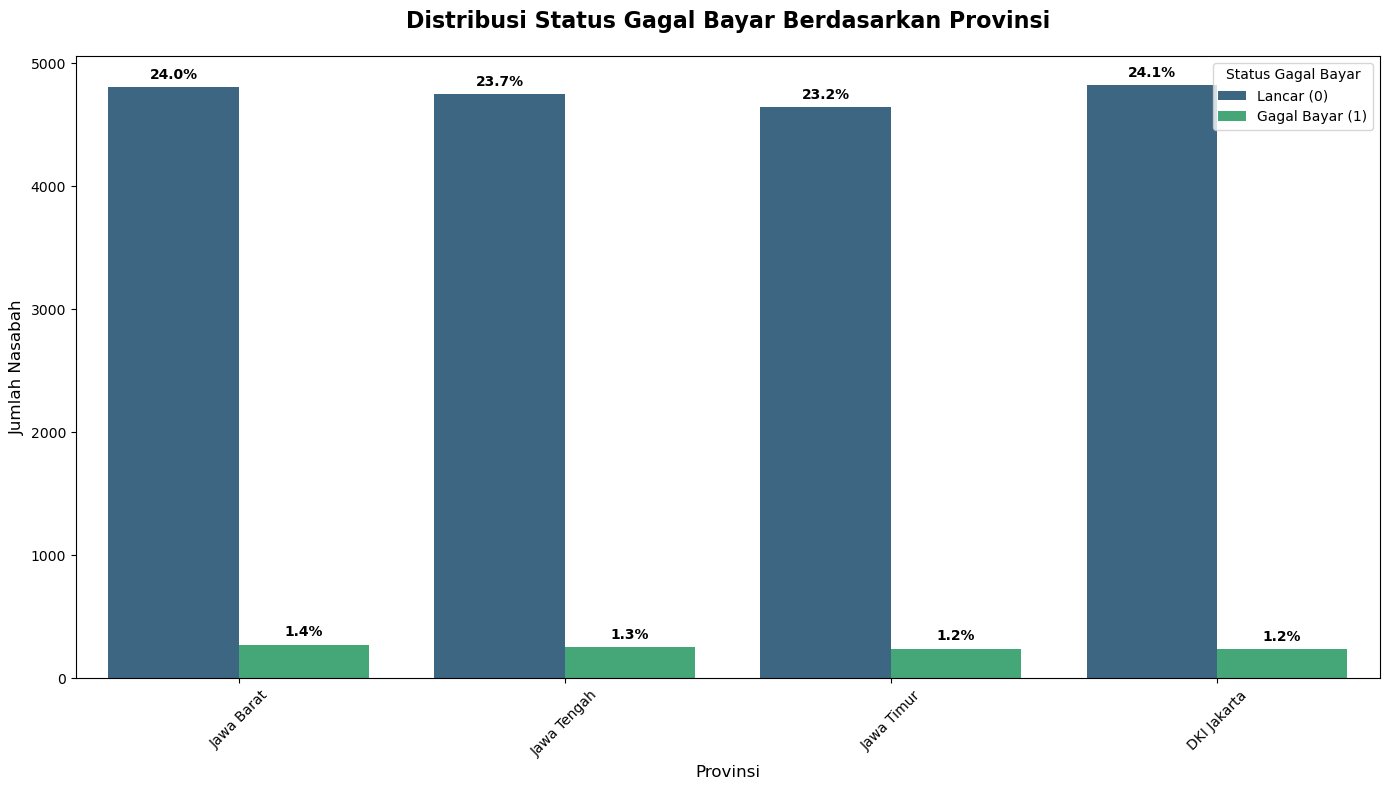

In [262]:
# define figure and countplot
plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=df_train, 
    x='provinsi', 
    hue='status_gagal_bayar', 
    palette='viridis'
)
# customize plot
plt.title('Distribusi Status Gagal Bayar Berdasarkan Provinsi', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Provinsi', fontsize=12)
plt.ylabel('Jumlah Nasabah', fontsize=12)
plt.legend(title='Status Gagal Bayar', labels=['Lancar (0)', 'Gagal Bayar (1)'])
total_data = len(df_train)
for p in ax.patches:
    # get height (amount of data)
    height = p.get_height()
    
    # calculate percentage
    percentage = f'{100 * height / total_data:.1f}%'
    
    # add percentage on a bar
    if height > 0:
        ax.annotate(
            percentage, 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='center', 
            xytext=(0, 9), 
            textcoords='offset points',
            fontsize=10,
            fontweight='semibold'
        )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.3.4 Check for Rare Events and Anomalies

In [263]:
mask_pengembalian_less_than_pinjaman = df_train[df_train['total_pengembalian'] < df_train['jumlah_pinjaman']]
print("banyak transaksi dengan total pengembalian kurang dari jumlah pinjaman-nya: ", len(mask_pengembalian_less_than_pinjaman))

banyak transaksi dengan total pengembalian kurang dari jumlah pinjaman-nya:  12


### 3.4 Check for Duplicate Row

In [264]:
print(df_train[df_train.duplicated()].shape[0])

0


## 4. Pre-processing and Feature Engineering

### 4.1 Treatment on `durasi_hari` and `jenis_pinjaman`

In [265]:
# anomaly handling of durasi_hari < 0
for df in [df_train, df_test]:
    df['is_durasi_hari_negative'] = (df['durasi_hari'] < 0).astype(int)
    df.loc[df['durasi_hari'] < 0, 'durasi_hari'] = np.nan

# missing value handling of durasi_hari: using median of durasi_hari per jenis_pinjaman
df_train['durasi_hari'] = df_train['durasi_hari'].fillna(df_train.groupby('jenis_pinjaman')['durasi_hari'].transform('median'))
median_map = df_train.groupby('jenis_pinjaman')['durasi_hari'].median().to_dict()
df_test['durasi_hari'] = df_test['durasi_hari'].fillna(df_test['jenis_pinjaman'].map(median_map))

# sort by tanggal_pencairan
df_train = df_train.sort_values("tanggal_pencairan").reset_index(drop=True)
df_test  = df_test.sort_values("tanggal_pencairan").reset_index(drop=True)

# missing value handling of jenis_pinjaman: using forward fill, backward fill, and grouped-by durasi_hari
df_train['jenis_pinjaman'] = df_train.groupby('durasi_hari')['jenis_pinjaman'].transform(lambda x: x.ffill().bfill())
df_test['jenis_pinjaman']  = df_test.groupby('durasi_hari')['jenis_pinjaman'].transform(lambda x: x.ffill().bfill())

# missing value handling of jenis_pinjaman: 1st fallback based on nearest duration
def get_nearest_jenis_pinjaman(durasi, median_dict):
    differences = {loan_type: abs(durasi - val) for loan_type, val in median_dict.items()}
    return min(differences, key=differences.get)
def fill_loan_type_by_nearest(df, median_dict):
    mask = df['jenis_pinjaman'].isna() & df['durasi_hari'].notna()
    df.loc[mask, 'jenis_pinjaman'] = df.loc[mask, 'durasi_hari'].apply(lambda d: get_nearest_jenis_pinjaman(d, median_dict))
    return df
df_train = fill_loan_type_by_nearest(df_train, median_map)
df_test  = fill_loan_type_by_nearest(df_test, median_map)

# missing value handling of jenis_pinjaman: 2nd fallback using forward fill and backward fill
df_train["jenis_pinjaman"] = df_train["jenis_pinjaman"].ffill().bfill()
df_test["jenis_pinjaman"] = df_test["jenis_pinjaman"].ffill().bfill()

# re-sort by id_transaksi
df_train = df_train.sort_values("id_transaksi").reset_index(drop=True)
df_test  = df_test.sort_values("id_transaksi").reset_index(drop=True)

# missing value handling of durasi_hari: 1st fallback based on jenis_pinjaman which the missing values have been filled up
df_train['durasi_hari'] = df_train['durasi_hari'].fillna(df_train['jenis_pinjaman'].map(median_map))
df_test['durasi_hari']  = df_test['durasi_hari'].fillna(df_test['jenis_pinjaman'].map(median_map))

### 4.2 Treatment on `tanggal_pencairan`

In [266]:
all_dates = pd.concat([df_train['tanggal_pencairan'], df_test['tanggal_pencairan']]).max()
reference_date = all_dates + pd.Timedelta(days=1)

def extract_time_features(df, date_column='tanggal_pencairan'): 
    df['durasi_hari_sejak_pencairan'] = (reference_date - df['tanggal_pencairan']).dt.days
    df['tahun'] = df[date_column].dt.year
    df['bulan'] = df[date_column].dt.month
    df['hari_dalam_bulan'] = df[date_column].dt.day
    df['hari_dalam_minggu'] = df[date_column].dt.dayofweek
    df['kuartal'] = df[date_column].dt.quarter
    df['is_weekend'] = df['hari_dalam_minggu'].apply(lambda x: 1 if x >= 5 else 0)
    df = df.drop(columns=[date_column], errors='ignore')
    return df

df_train = extract_time_features(df_train.copy())
df_test = extract_time_features(df_test.copy())

In [267]:
def cyclic_transformation(df):
    df['bulan_sin'] = np.sin(2 * np.pi * df['bulan'] / 12)
    df['bulan_cos'] = np.cos(2 * np.pi * df['bulan'] / 12)
    df['hari_bulan_sin'] = np.sin(2 * np.pi * df['hari_dalam_bulan'] / 31)
    df['hari_bulan_cos'] = np.cos(2 * np.pi * df['hari_dalam_bulan'] / 31)
    df = df.drop(columns=['bulan', 'hari_dalam_bulan'], errors='ignore')
    return df

df_train = cyclic_transformation(df_train.copy())
df_test = cyclic_transformation(df_test.copy())

### 4.3 Treatment on `total_pengembalian` and `porsi_pengembalian_lender`

In [268]:
def handle_illogical_total_pengembalian(df):
    illogical_condition = (df['total_pengembalian'] < df['jumlah_pinjaman'])
    # binary flagging
    df['is_total_pengembalian_illogical'] = illogical_condition.astype(int)
    # capping total_pengembalian into as same as its jumlah_pinjaman
    df.loc[illogical_condition, 'total_pengembalian'] = df.loc[illogical_condition, 'jumlah_pinjaman']
    return df

df_train = handle_illogical_total_pengembalian(df_train)
df_test = handle_illogical_total_pengembalian(df_test)

In [269]:
# calculate the global median of ratio between total_pengembalian and jumlah_pinjaman from valid set
mask_valid = df_train['total_pengembalian'].notna() & df_train['jumlah_pinjaman'].notna()
median_global_of_ratio = (df_train.loc[mask_valid, 'total_pengembalian'] / df_train.loc[mask_valid, 'jumlah_pinjaman']).median()

# mask the valid sets to impute on
mask_train = df_train['total_pengembalian'].isna() & df_train['jumlah_pinjaman'].notna()
mask_test  = df_test['total_pengembalian'].isna() & df_test['jumlah_pinjaman'].notna()

# fill the missing values by multiplying its jumlah_pinjaman with median_global_of_ratio
df_train.loc[mask_train, 'total_pengembalian'] = df_train['jumlah_pinjaman'] * median_global_of_ratio
df_test.loc[mask_test, 'total_pengembalian']   = df_test['jumlah_pinjaman'] * median_global_of_ratio

In [270]:
# calculate the ratio between porsi_pengembalian_lender and total_pengembalian from valid set
mask_valid = df_train['porsi_pengembalian_lender'].notna() & df_train['total_pengembalian'].notna()
ratio = df_train.loc[mask_valid, 'porsi_pengembalian_lender'] / df_train.loc[mask_valid, 'total_pengembalian']

# calculate the global median of ratio and grouped-by median of ratio
median_per_grup = ratio.groupby(df_train.loc[mask_valid, 'jenis_pinjaman']).median()
median_global = ratio.median()

# map the ratio with global median as a fallback
ratio_final_train = df_train['jenis_pinjaman'].map(median_per_grup).fillna(median_global)
ratio_final_test = df_test['jenis_pinjaman'].map(median_per_grup).fillna(median_global)

# mask the valid sets to impute on
mask_missing_train = df_train['porsi_pengembalian_lender'].isna() & df_train['total_pengembalian'].notna()
mask_missing_test = df_test['porsi_pengembalian_lender'].isna() & df_test['total_pengembalian'].notna()

# fill the missing values by multiplying its total_pengembalian with the ratio defined
df_train.loc[mask_missing_train, 'porsi_pengembalian_lender'] = df_train['total_pengembalian'] * ratio_final_train
df_test.loc[mask_missing_test, 'porsi_pengembalian_lender'] = df_test['total_pengembalian'] * ratio_final_test

In [271]:
# drop rows from train set which have total_pengembalian = 0, jumlah_pinjaman = 0, and total_pengembalian = 0
df_train = df_train.loc[(df_train['total_pengembalian'] != 0) | (df_train['jumlah_pinjaman'] != 0) | (df_train['porsi_pengembalian_lender'] != 0)].copy()

In [272]:
# handle df_test with total_pengembalian = 0, jumlah_pinjaman = 0, and total_pengembalian = 0 
cond = (df_test["jumlah_pinjaman"] == 0) & (df_test["total_pengembalian"] == 0) & (df_test["porsi_pengembalian_lender"] == 0)

# get the grouped-by jenis_pinjaman median of jumlah_pinjaman
median_pinjaman = df_train.groupby("jenis_pinjaman")["jumlah_pinjaman"].median()

# get the grouped-by jenis_pinjaman median of the ratio between total_pengembalian and jumlah_pinjaman from the valid set
train_p_valid = df_train[(df_train["total_pengembalian"] > 0) & (df_train["jumlah_pinjaman"] > 0)]
rasio_kembali = (train_p_valid["total_pengembalian"] / train_p_valid["jumlah_pinjaman"]).groupby(train_p_valid["jenis_pinjaman"]).median()

# get the grouped-by jenis_pinjaman median of the ratio between porsi_pengembalian_lender and total_pengembalian from the valid set
train_l_valid = df_train[df_train["total_pengembalian"] > 0]
rasio_lender = (train_l_valid["porsi_pengembalian_lender"] / train_l_valid["total_pengembalian"]).groupby(train_l_valid["jenis_pinjaman"]).median()

# apply imputation
df_test.loc[cond, "jumlah_pinjaman"] = df_test.loc[cond, "jenis_pinjaman"].map(median_pinjaman)
df_test.loc[cond, "total_pengembalian"] = df_test.loc[cond, "jumlah_pinjaman"] * df_test.loc[cond, "jenis_pinjaman"].map(rasio_kembali)
df_test.loc[cond, "porsi_pengembalian_lender"] = df_test.loc[cond, "total_pengembalian"] * df_test.loc[cond, "jenis_pinjaman"].map(rasio_lender)

### 4.4 Feature Engineering

In [273]:
df_train['rasio_kembali'] = df_train['total_pengembalian'] / df_train['jumlah_pinjaman']
df_test['rasio_kembali']  = df_test['total_pengembalian'] / df_test['jumlah_pinjaman']

In [274]:
kategori_produktif = ['Modal_Usaha', 'Investasi', 'Mikro_UKM']
kategori_konsumtif = ['Konsumtif', 'Multiguna']

for df in [df_train, df_test]:
    df['flag_is_produktif_group'] = df['jenis_pinjaman'].isin(kategori_produktif).astype(int)
    df['flag_is_konsumtif_group'] = df['jenis_pinjaman'].isin(kategori_konsumtif).astype(int)

In [275]:
df_train['is_zero_interest'] = np.isclose(df_train['jumlah_pinjaman'], df_train['total_pengembalian'], atol=1.0).astype(int)
df_test['is_zero_interest'] = np.isclose(df_test['jumlah_pinjaman'], df_test['total_pengembalian'], atol=1.0).astype(int)

In [276]:
df_train['is_lender_return_zero'] = (df_train['porsi_pengembalian_lender'] == 0).astype(int)
df_test['is_lender_return_zero'] = (df_test['porsi_pengembalian_lender'] == 0).astype(int)

In [277]:
df_train['rasio_lender'] = df_train['porsi_pengembalian_lender'] / df_train['total_pengembalian']
df_test['rasio_lender'] = df_test['porsi_pengembalian_lender'] / df_test['total_pengembalian']

In [278]:
df_train['lender_return_per_pinjaman'] = df_train['porsi_pengembalian_lender'] / df_train['jumlah_pinjaman']
df_test['lender_return_per_pinjaman'] = df_test['porsi_pengembalian_lender'] / df_test['jumlah_pinjaman']

In [279]:
df_train['biaya_harian'] = (df_train['total_pengembalian'] -  df_train['jumlah_pinjaman']) / df_train['durasi_hari']
df_test['biaya_harian'] = (df_test['total_pengembalian'] -  df_test['jumlah_pinjaman']) / df_test['durasi_hari']

In [280]:
for df in [df_train, df_test]:
    df['is_high_risk_cohort'] = ((df['status_peminjam'] == 'Peminjam_Baru') & (df['tahun'] == 2022)).astype(int)

In [281]:
# feature transformation: log transformation
numerical_to_transform = ['jumlah_pinjaman', 'total_pengembalian', 'porsi_pengembalian_lender', 'biaya_harian']
for col in numerical_to_transform:
     df_train[col] = np.log1p(df_train[col])
     df_test[col] = np.log1p(df_test[col])

In [282]:
# percentile capping for non tree based models
df_train_non_tree = df_train.copy()
df_test_non_tree = df_test.copy()
lower_percentile = 0.01
upper_percentile = 0.99
percentile_limits = {}
for col in numerical:
    lower = df_train_non_tree[col].quantile(lower_percentile)
    upper = df_train_non_tree[col].quantile(upper_percentile)
    percentile_limits[col] = (lower, upper)
    df_train_non_tree[col] = df_train_non_tree[col].clip(lower, upper)
    df_test_non_tree[col] = df_test_non_tree[col].clip(lower, upper)

In [283]:
# treat tahun, kuartal, and hari_dalam_minggu as categorical features
def toObject(df):
    df['tahun'] = df['tahun'].astype(str)
    df['kuartal'] = df['kuartal'].astype(str)
    df['hari_dalam_minggu'] = df['hari_dalam_minggu'].astype(str)
    return df

df_train = toObject(df_train)
df_train_non_tree = toObject(df_train_non_tree)
df_test = toObject(df_test)
df_test_non_tree = toObject(df_test_non_tree)

In [284]:
# define categorical features for encoding needs
ohe_features = ['provinsi', 'jenis_pinjaman', 'sektor_usaha', 'jenis_jaminan', 'tahun', 'kuartal', 'hari_dalam_minggu']
ode_features = ['pendidikan']
edu_order = ['SMA','D3', 'S1', 'S2']
be_features = ['status_peminjam']
binary_categories = ['Peminjam_Berulang', 'Peminjam_Baru']

# ordinal encoding: manual mapping
edu_map = {grade: i for i, grade in enumerate(edu_order)}
for df in [df_train, df_test, df_train_non_tree, df_test_non_tree]:
    df['pendidikan'] = df['pendidikan'].map(edu_map)

# binary encoding: manual mapping
status_map = {binary_categories[1]: 0, binary_categories[0]: 1}
for df in [df_train, df_test, df_train_non_tree, df_test_non_tree]:
    df['status_peminjam'] = df['status_peminjam'].map(status_map)

# one-hot encoding: fit on train and transform only on test
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(df_train[ohe_features])
def apply_ohe(df, encoder, columns):
    encoded_cols = encoder.get_feature_names_out(columns)
    transformed_data = encoder.transform(df[columns])
    # create new dataframe from the encoding result
    df_encoded = pd.DataFrame(transformed_data, columns=encoded_cols, index=df.index)
    # concat and drop the original feature
    return pd.concat([df.drop(columns=columns), df_encoded], axis=1)
df_train = apply_ohe(df_train, ohe, ohe_features)
df_test = apply_ohe(df_test, ohe, ohe_features)
df_train_non_tree = apply_ohe(df_train_non_tree, ohe, ohe_features)
df_test_non_tree = apply_ohe(df_test_non_tree, ohe, ohe_features)

In [285]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20010 entries, 0 to 20011
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_transaksi                     20010 non-null  int64  
 1   status_peminjam                  20010 non-null  int64  
 2   jumlah_pinjaman                  20010 non-null  float64
 3   total_pengembalian               20010 non-null  float64
 4   durasi_hari                      20010 non-null  float64
 5   porsi_pengembalian_lender        20010 non-null  float64
 6   pendidikan                       20010 non-null  int64  
 7   status_gagal_bayar               20010 non-null  int64  
 8   is_durasi_hari_negative          20010 non-null  int64  
 9   durasi_hari_sejak_pencairan      20010 non-null  int64  
 10  is_weekend                       20010 non-null  int64  
 11  bulan_sin                        20010 non-null  float64
 12  bulan_cos              

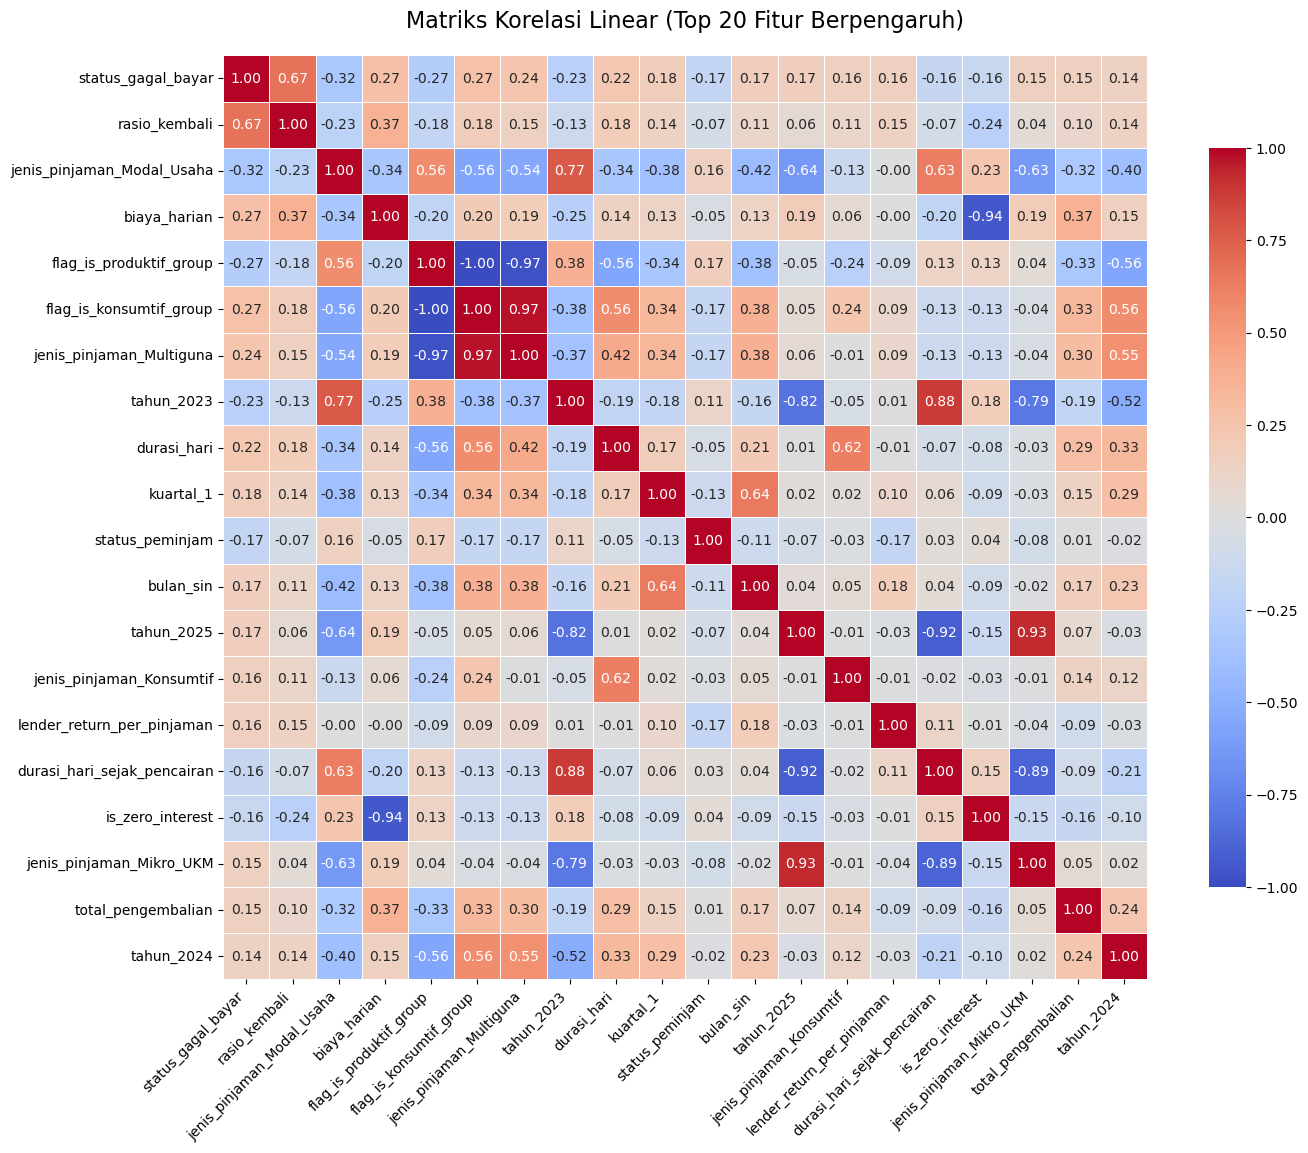

In [286]:
target_col = 'status_gagal_bayar'
target_corr = df_train.corr(method='pearson')[[target_col]]
top_20_features = target_corr.abs().nlargest(20, target_col).index
plt.figure(figsize=(16, 12))

sns.heatmap(
    df_train[top_20_features].corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriks Korelasi Linear (Top 20 Fitur Berpengaruh)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

In [287]:
# feature selection: prevent multicolinearity

# non tree (mandatory) 
df_train_non_tree = df_train_non_tree.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')
df_test_non_tree = df_test_non_tree.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')

# tree (preferable) 
df_train = df_train.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')
df_test = df_test.drop(columns=['jumlah_pinjaman', 'rasio_lender'], errors='ignore')

In [288]:
chi_cols = [
    'is_durasi_hari_negative', 'is_weekend', 'is_total_pengembalian_illogical',
    'is_lender_return_zero', 'status_peminjam',
    'provinsi_DKI Jakarta', 'provinsi_Jawa Barat', 'provinsi_Jawa Tengah', 'provinsi_Jawa Timur',
    'jenis_pinjaman_Investasi', 'jenis_pinjaman_Konsumtif', 'jenis_pinjaman_Mikro_UKM', 
    'jenis_pinjaman_Modal_Usaha', 'jenis_pinjaman_Multiguna',
    'sektor_usaha_Digital', 'sektor_usaha_Jasa', 'sektor_usaha_Kuliner', 
    'sektor_usaha_Manufaktur', 'sektor_usaha_Perdagangan', 'sektor_usaha_Pertanian',
    'jenis_jaminan_BPKB', 'jenis_jaminan_SK_Pegawai', 'jenis_jaminan_Sertifikat',
    'jenis_jaminan_Tanpa_Jaminan',
    'tahun_2022', 'tahun_2023', 'tahun_2024', 'tahun_2025',
    'kuartal_1', 'kuartal_2', 'kuartal_3', 'kuartal_4',
    'hari_dalam_minggu_0', 'hari_dalam_minggu_1', 'hari_dalam_minggu_2',
    'hari_dalam_minggu_3', 'hari_dalam_minggu_4', 'hari_dalam_minggu_5',
    'hari_dalam_minggu_6','is_zero_interest'
]

X_chi = df_train[chi_cols]
y_chi = df_train['status_gagal_bayar']
chi_scores, p_vals = chi2(X_chi, y_chi)
pd.DataFrame({
    'feature': chi_cols,
    'chi2_score': chi_scores,
    'p_value': p_vals
}).sort_values('p_value')

,feature,chi2_score,p_value
13,jenis_pinjaman_Multiguna,"1,095.10",0.00
28,kuartal_1,617.47,0.00
27,tahun_2025,529.13,0.00
10,jenis_pinjaman_Konsumtif,511.71,0.00
11,jenis_pinjaman_Mikro_UKM,448.47,0.00
26,tahun_2024,387.68,0.00
39,is_zero_interest,330.92,0.00
29,kuartal_2,316.94,0.00
24,tahun_2022,281.47,0.00
9,jenis_pinjaman_Investasi,240.31,0.00


In [289]:
# feature selection: binary features vs binary target chi-square based
cols_to_drop = ['is_durasi_hari_negative', 'provinsi_Jawa Barat', 'provinsi_DKI Jakarta', 'provinsi_Jawa Timur', 'provinsi_Jawa Tengah']

df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test = df_test.drop(columns=cols_to_drop, errors='ignore')

df_train_non_tree = df_train_non_tree.drop(columns=cols_to_drop, errors='ignore')
df_test_non_tree = df_test_non_tree.drop(columns=cols_to_drop, errors='ignore')

In [290]:
# feature selection: irrelevant feature
df_train = df_train.drop(columns=['id_transaksi'], errors='ignore')
df_train_non_tree = df_train_non_tree.drop(columns=['id_transaksi'], errors='ignore')

## 5. Model Development

In [291]:
# split features and target variable

# store test ids
test_ids= df_test['id_transaksi'].copy()

# get target column of train set
y_train = df_train['status_gagal_bayar'].copy()

# get features of train set and test set
X_train_non_tree = df_train_non_tree.drop(columns=['status_gagal_bayar'])
X_test_non_tree = df_test_non_tree.drop(columns=['id_transaksi'], errors='ignore')
X_train_tree = df_train.drop(columns=['status_gagal_bayar'])
X_test_tree = df_test.drop(columns=['id_transaksi'], errors='ignore')

In [292]:
# imbalanced class handling needs for XGB and LGBM
minority_class_count = (y_train == 1).sum()
majority_class_count = (y_train == 0).sum()
scale_pos_weight_value = math.sqrt(majority_class_count/minority_class_count)
print(f"Proporsi Gagal Bayar (Kelas 1): {minority_class_count / len(y_train) * 100:.2f}%")
print(f"Nilai scale_pos_weight untuk XGBoost/LightGBM: {scale_pos_weight_value:.2f}")

Proporsi Gagal Bayar (Kelas 1): 5.03%
Nilai scale_pos_weight untuk XGBoost/LightGBM: 4.35


In [293]:
# data splitting needs: initialize 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [294]:
# =============================
#       MODEL SELECTION
# =============================

# Logistic Regression
numerical_to_standardize = ['total_pengembalian', 'durasi_hari', 'porsi_pengembalian_lender', 'rasio_kembali']
passthrough_columns = [col for col in X_train_non_tree.columns.tolist() if col not in numerical_to_standardize]
lr_preprocessor = ColumnTransformer(transformers=[('num_scale', StandardScaler(), numerical_to_standardize), ('other_pass', 'passthrough', passthrough_columns)], remainder='drop')
logreg_pipeline = Pipeline([('preprocessor', lr_preprocessor), ('logreg', LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced', random_state=SEED))])
lr_scores = cross_val_score(logreg_pipeline, X_train_non_tree, y_train, cv=skf, scoring='f1_macro')
lr_mean = np.mean(lr_scores)
lr_std = np.std(lr_scores)
print(f"Logistic Regression - Macro F1 CV Score: {lr_mean:.4f} (+/- {lr_std:.4f})")

# KNN
knn_preprocessor = ColumnTransformer(transformers=[('num_scale', StandardScaler(), numerical_to_standardize), ('other_pass', 'passthrough', passthrough_columns)],remainder='drop')
knn_pipe = Pipeline([('preprocessor', knn_preprocessor), ('knn', KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1))])
knn_scores = cross_val_score(knn_pipe, X_train_non_tree, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"KNN CV Macro F1: {knn_scores.mean():.4f} (+/- {knn_scores.std():.4f})")

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth = 10, min_samples_leaf = 5, class_weight = 'balanced', random_state = SEED)
dt_scores = cross_val_score(dt_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"Decision Tree - Macro F1 CV Score: {np.mean(dt_scores):.4f} (+/- {np.std(dt_scores):.4f})")

# Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, class_weight = 'balanced', n_jobs = -1, random_state=SEED)
rf_scores = cross_val_score(rf_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"Random Forest - Macro F1 CV Score: {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators = 500, max_depth = 6, learning_rate = 0.1, scale_pos_weight = scale_pos_weight_value, use_label_encoder = False, eval_metric = 'logloss', random_state = SEED)
xgb_scores = cross_val_score(xgb_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"XGBoost - Macro F1 CV Score: {np.mean(xgb_scores):.4f} (+/- {np.std(xgb_scores):.4f})")

# lgbm
lgb_model = lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight_value, random_state=SEED)
lgb_scores = cross_val_score(lgb_model, X_train_tree, y_train, cv=skf, scoring='f1_macro')
print(f"LightGBM - Macro F1 CV Score: {np.mean(lgb_scores):.4f} (+/- {np.std(lgb_scores):.4f})")

Logistic Regression - Macro F1 CV Score: 0.7594 (+/- 0.0093)
KNN CV Macro F1: 0.7910 (+/- 0.0112)
Decision Tree - Macro F1 CV Score: 0.8801 (+/- 0.0080)
Random Forest - Macro F1 CV Score: 0.9254 (+/- 0.0105)
XGBoost - Macro F1 CV Score: 0.9371 (+/- 0.0136)
[LightGBM] [Info] Number of positive: 805, number of negative: 15203
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1708
[LightGBM] [Info] Number of data points in the train set: 16008, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050287 -> initscore=-2.938406
[LightGBM] [Info] Start training from score -2.938406
[LightGBM] [Info] Number of positive: 805, number of negative: 15203
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000667 seconds.
You can set `f

*Inference*: kita di sini mengambil XGB sebagai model utama yang akan coba di-*tune*.

In [295]:
# define parameters
param_grid_xgb = {
    'max_depth': [5, 8, 10, 12], 
    'learning_rate': [0.01, 0.03, 0.05, 0.08], 
    'n_estimators': [600, 1000, 1500, 2000], 
    'gamma': [0.0, 0.1, 0.2, 0.3], 
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

# base model
xgb_base = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight_value, use_label_encoder=False, eval_metric='logloss', random_state=SEED)

# Randomized Search: to perform hyperparameter tuning
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=50, # Jumlah kombinasi untuk diuji
    scoring='f1_macro',
    cv=skf,
    verbose=2,
    n_jobs=-1,
    random_state=SEED
)
random_search_xgb.fit(X_train_tree, y_train)

# save best model
xgb_tuned_clf = random_search_xgb.best_estimator_
best_xgb_score = random_search_xgb.best_score_

print(f"XGBoost TUNED Macro F1: {best_xgb_score:.4f}")
print("Best Params:", random_search_xgb.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
XGBoost TUNED Macro F1: 0.9407
Best Params: {'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 12, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [297]:
# define more robust model evaluation for tuned model
def evaluate_model(tuned_model, X, y, cv, model_name=""):
    # get CV evaluation score
    cv_scores = cross_val_score(tuned_model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    # get train evaluation score 
    tuned_model.fit(X, y)
    train_pred = tuned_model.predict(X)
    train_score = f1_score(y, train_pred, average="macro")
    # return all result of evaluation
    return {
        "model": model_name,
        "train_f1": train_score,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

# apply the evaluation to tuned model
xgb_tuned_result = evaluate_model(
    tuned_model=xgb_tuned_clf, 
    X=X_train_tree, 
    y=y_train, 
    cv=skf, 
    model_name="XGBoost (Tuned)"
)

# display result
print("XGBoost Tuned Result:")
with pd.option_context('display.float_format', '{:.7f}'.format):
    display(pd.Series(xgb_tuned_result))

XGBoost Tuned Result:


model       XGBoost (Tuned)
train_f1          1.0000000
cv_mean           0.9406781
cv_std            0.0114705
dtype: object

In [298]:
# produce Out-of-Fold (OOF) probabilities using 5-fold CV
# in order to find threshold without seeing actual test data
print("Mengestimasi probabilitas OOF menggunakan Cross-Validation...")
y_proba_oof = cross_val_predict(
    xgb_tuned_clf, 
    X_train_tree, 
    y_train, 
    cv=skf, 
    method='predict_proba', 
    n_jobs=-1
)[:, 1]

# find optimal threshold based on Macro F1-Score only
# range to try out [0.05 till 0.50]
thresholds = np.arange(0.05, 0.51, 0.005)
scores = []

for t in thresholds:
    # convert probabilities into a label (0 or 1) based on threshold t
    y_pred_temp = (y_proba_oof >= t).astype(int)
    score = f1_score(y_train, y_pred_temp, average='macro')
    scores.append(score)

# get best value
best_idx = np.argmax(scores)
optimal_threshold = thresholds[best_idx]
best_f1_score = scores[best_idx]
print(f"\n=== OPTIMIZATION FINISHED ===")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"Best Macro F1    : {best_f1_score:.4f}")

# final training and predict on test data
# fit model on whole train set
print("\nMelatih model pada seluruh data training...")
xgb_tuned_clf.fit(X_train_tree, y_train)

# get probabilities for test data
test_probas = xgb_tuned_clf.predict_proba(X_test_tree)[:, 1]

# apply optimal threshold gotten from 5-fold CV process
test_predictions = (test_probas >= optimal_threshold).astype(int)

# create submission file
submission_df = pd.DataFrame({
    'id_transaksi': test_ids,
    'status_gagal_bayar': test_predictions
})
submission_df.to_csv('data/submission_refactored_version.csv', index=False)
print("file submission berhasil disimpan!")

Mengestimasi probabilitas OOF menggunakan Cross-Validation...

=== OPTIMIZATION FINISHED ===
Optimal Threshold: 0.500
Best Macro F1    : 0.9406

Melatih model pada seluruh data training...
file submission berhasil disimpan!


In [301]:
# Define directory
MODEL_DIR = 'model'
os.makedirs(MODEL_DIR, exist_ok=True)

# Keep model: XGB
MODEL_FILE_NAME = 'xgb_model_refactored.pkl'
joblib.dump(xgb_tuned_clf, os.path.join(MODEL_DIR, MODEL_FILE_NAME))
print(f"Model XGB refactored tersimpan di: {MODEL_DIR}/{MODEL_FILE_NAME}")

Model XGB refactored tersimpan di: model/xgb_model_refactored.pkl
